In [175]:
import pandas as pd
import numpy as np

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

pd.set_option('display.max_columns', None)

# Show all rows
pd.set_option('display.max_rows', None)

# Cards Data

## Cleaning

In [2]:
def wrangle_card_data(cards_data):
    
    cards_data['expires'] = pd.to_datetime(cards_data['expires'], format='%m/%Y', errors='coerce') + pd.offsets.MonthEnd(0)
    cards_data['acct_open_date'] = pd.to_datetime(cards_data['acct_open_date'], format='%m/%Y', errors='coerce') + pd.offsets.MonthEnd(0)
    
    cards_data['has_chip'] = np.where(cards_data['has_chip'] == 'YES', 1, 0)
    cards_data['card_on_dark_web'] = np.where(cards_data['card_on_dark_web'] == 'No', 0, 1)

    cards_data['credit_limit'] = cards_data['credit_limit'].str.replace('$', '')
    cards_data['credit_limit'] = cards_data['credit_limit'].astype(float)

    return cards_data

In [3]:
cards_data = pd.read_csv('cards_data.csv')
cards_data = wrangle_card_data(cards_data)
cards_data.head()

,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
0,4524,825,Visa,Debit,4344676511950444,2022-12-31,623,1,2,24295.0,2002-09-30,2008,0
1,2731,825,Visa,Debit,4956965974959986,2020-12-31,393,1,2,21968.0,2014-04-30,2014,0
2,3701,825,Visa,Debit,4582313478255491,2024-02-29,719,1,2,46414.0,2003-07-31,2004,0
3,42,825,Visa,Credit,4879494103069057,2024-08-31,693,0,1,12400.0,2003-01-31,2012,0
4,4659,825,Mastercard,Debit (Prepaid),5722874738736011,2009-03-31,75,1,1,28.0,2008-09-30,2009,0


In [4]:
cards_data.duplicated().sum()

np.int64(0)

In [5]:
cards_data.dtypes

id                                int64
client_id                         int64
card_brand                       object
card_type                        object
card_number                       int64
expires                  datetime64[ns]
cvv                               int64
has_chip                          int64
num_cards_issued                  int64
credit_limit                    float64
acct_open_date           datetime64[ns]
year_pin_last_changed             int64
card_on_dark_web                  int64
dtype: object

In [6]:
#cards_data.isna().sum() # 0 nulls values are there

<Axes: ylabel='proportion'>

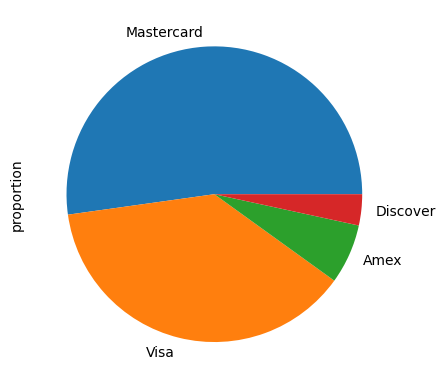

In [7]:
cards_data['card_brand'].value_counts(normalize=True).plot(kind = 'pie')

<Axes: ylabel='proportion'>

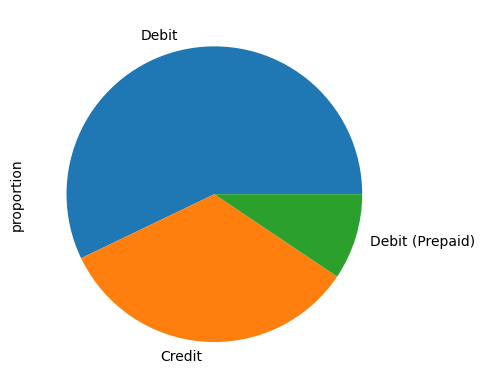

In [8]:
cards_data['card_type'].value_counts(normalize=True).plot(kind = 'pie')

In [9]:
cards_data['card_on_dark_web'].value_counts()

card_on_dark_web
0    6146
Name: count, dtype: int64

<Axes: title={'center': 'distribution of credit_limit'}, ylabel='Frequency'>

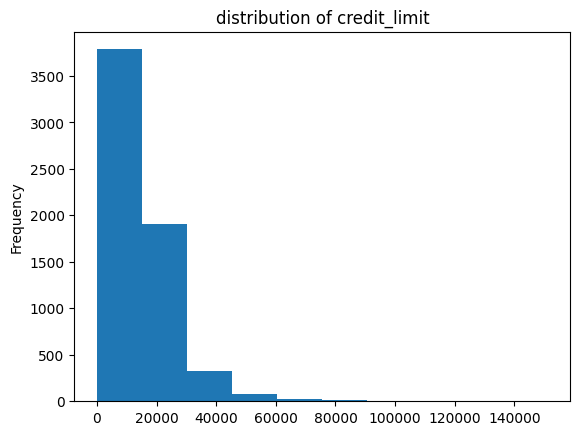

In [10]:
cards_data['credit_limit'].plot(kind = 'hist', title = 'distribution of credit_limit')

In [11]:
cards_data.dtypes

id                                int64
client_id                         int64
card_brand                       object
card_type                        object
card_number                       int64
expires                  datetime64[ns]
cvv                               int64
has_chip                          int64
num_cards_issued                  int64
credit_limit                    float64
acct_open_date           datetime64[ns]
year_pin_last_changed             int64
card_on_dark_web                  int64
dtype: object

# Transactions Data

## Cleaning

In [94]:
def wrangle_transactions_data(transactions_data):
    
    transactions_data['date'] = pd.to_datetime(transactions_data['date'])

    errors_split = transactions_data['errors'].str.split(',', expand=True)

    # Flatten all possible error types into a single list
    all_error_types = errors_split.stack().unique()

    # Create new columns for each error type and flag presence
    for error in all_error_types:
        transactions_data[error] = transactions_data['errors'].apply(lambda x: 1 if error in str(x) else 0)


    transactions_data['amount'] = transactions_data['amount'].str.replace('$', '')
    transactions_data['amount'] = transactions_data['amount'].astype(float)


    #these are the rows where the amount is negative and erorrs are there which do replicate a customer behaviour so I am deciding to exclude these columns
    transactions_data = transactions_data[~((transactions_data['amount'] < 0) & (~transactions_data['errors'].isna()))]
    transactions_data.drop(columns='errors', inplace = True)

    return transactions_data


In [95]:
transactions_data = pd.read_csv('transactions_data.csv')
transactions_data = wrangle_transactions_data(transactions_data)
transactions_data.head()

C:\Users\Vinay\AppData\Local\Temp\ipykernel_9520\3206127613.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transactions_data.drop(columns='errors', inplace = True)


,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,Technical Glitch,Bad Expiration,Bad Card Number,Insufficient Balance,Bad PIN,Bad CVV,Bad Zipcode
0,7475327,2010-01-01 00:01:00,1556,2972,-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,0,0,0,0,0,0,0
1,7475328,2010-01-01 00:02:00,561,4575,14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,0,0,0,0,0,0,0
2,7475329,2010-01-01 00:02:00,1129,102,80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,0,0,0,0,0,0,0
3,7475331,2010-01-01 00:05:00,430,2860,200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,4829,0,0,0,0,0,0,0
4,7475332,2010-01-01 00:06:00,848,3915,46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,0,0,0,0,0,0,0


In [97]:
transactions_data.loc[transactions_data['amount'] < 0]

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,Technical Glitch,Bad Expiration,Bad Card Number,Insufficient Balance,Bad PIN,Bad CVV,Bad Zipcode
0,7475327,2010-01-01 00:01:00,1556,2972,-77.0,Swipe Transaction,59935,Beulah,ND,58523.0,5499,0,0,0,0,0,0,0
19,7475347,2010-01-01 00:36:00,114,3398,-64.0,Swipe Transaction,61195,North Hollywood,CA,91606.0,5541,0,0,0,0,0,0,0
50,7475382,2010-01-01 01:25:00,1703,2969,-78.0,Swipe Transaction,43293,Grand Junction,CO,81506.0,5499,0,0,0,0,0,0,0
81,7475422,2010-01-01 02:13:00,1453,1117,-460.0,Swipe Transaction,5009,Middletown,NY,10940.0,7011,0,0,0,0,0,0,0
114,7475460,2010-01-01 03:08:00,957,4532,-147.0,Swipe Transaction,44795,Marysville,OH,43040.0,3780,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13305780,23761706,2019-10-31 22:13:00,1360,143,-91.0,Chip Transaction,59935,Crestview,FL,32536.0,5499,0,0,0,0,0,0,0
13305811,23761745,2019-10-31 22:28:00,194,5587,-71.0,Swipe Transaction,59935,Hartford City,IN,47348.0,5499,0,0,0,0,0,0,0
13305813,23761747,2019-10-31 22:29:00,133,4683,-52.0,Chip Transaction,61195,Marietta,GA,30067.0,5541,0,0,0,0,0,0,0
13305820,23761757,2019-10-31 22:35:00,260,323,-77.0,Chip Transaction,22204,Mission,TX,78572.0,5541,0,0,0,0,0,0,0


In [80]:
(transactions_data.isna().sum() / transactions_data.shape[0]) * 100

id                 0.000000
date               0.000000
client_id          0.000000
card_id            0.000000
amount             0.000000
use_chip           0.000000
merchant_id        0.000000
merchant_city      0.000000
merchant_state    11.751916
zip               12.420837
mcc                0.000000
errors            98.411286
dtype: float64

for empty values of state and zip the transactions are online and hence state is not mentioned.
for this first we create another feature as transaction type

In [81]:
transactions_data[transactions_data['merchant_state'].isna()]['use_chip'].value_counts()

use_chip
Online Transaction    1557912
Chip Transaction         5788
Name: count, dtype: int64

In [82]:
transactions_data.head()

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN
1,7475328,2010-01-01 00:02:00,561,4575,$14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,NaN
2,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN
3,7475331,2010-01-01 00:05:00,430,2860,$200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,4829,NaN
4,7475332,2010-01-01 00:06:00,848,3915,$46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,NaN


In [83]:
transactions_data.dtypes

id                  int64
date               object
client_id           int64
card_id             int64
amount             object
use_chip           object
merchant_id         int64
merchant_city      object
merchant_state     object
zip               float64
mcc                 int64
errors             object
dtype: object

In [ ]:

transactions_data['date'].head()

0   2010-01-01 00:01:00
1   2010-01-01 00:02:00
2   2010-01-01 00:02:00
3   2010-01-01 00:05:00
4   2010-01-01 00:06:00
Name: date, dtype: datetime64[ns]

In [ ]:
transactions_data['use_chip'].value_counts()

use_chip
Swipe Transaction     98048
Chip Transaction      68269
Online Transaction    35533
Name: count, dtype: int64

In [ ]:
transactions_data.columns

Index(['id', 'date', 'client_id', 'card_id', 'amount', 'use_chip',
       'merchant_id', 'merchant_city', 'merchant_state', 'zip', 'mcc',
       'Technical Glitch', 'Bad Expiration', 'Bad Card Number',
       'Insufficient Balance', 'Bad PIN', 'Bad CVV', 'Bad Zipcode'],
      dtype='object')

In [ ]:
transactions_data.shape

(201850, 20)

# User Data

## Cleaning

In [166]:
def wrangle_user_data(users_data):
    
    users_data['gender'] = np.where(users_data['gender'] == 'Female', 0, 1)
    users_data['per_capita_income'] = users_data['per_capita_income'].str.replace('$', '')
    users_data['per_capita_income'] = users_data['per_capita_income'].astype(float)
    users_data['yearly_income'] = users_data['yearly_income'].str.replace('$', '')
    users_data['yearly_income'] = users_data['yearly_income'].astype(float)

    users_data['total_debt'] = users_data['total_debt'].str.replace('$', '')
    users_data['total_debt'] = users_data['total_debt'].astype(float)


    #new feature
    users_data['debt_to_income_ratio'] = users_data['total_debt'] / users_data['yearly_income']
    users_data['income_vs_area'] = users_data['yearly_income'] - users_data['per_capita_income']


    #dropping less usefull for customer segmentation
    #retirement_age, we already have current age
    # address, we have long and lat if location is used
    # birth_month, we have year.
    users_data.drop(columns = ['address', 'retirement_age', 'birth_month'], inplace = True)


    return users_data

In [168]:
users_data = pd.read_csv('users_data.csv')
users_data = wrangle_user_data(users_data)
users_data.head()

,id,current_age,birth_year,gender,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards,debt_to_income_ratio,income_vs_area
0,825,53,1966,0,34.15,-117.76,29278.0,59696.0,127613.0,787,5,2.137714,30418.0
1,1746,53,1966,0,40.76,-73.74,37891.0,77254.0,191349.0,701,5,2.476881,39363.0
2,1718,81,1938,0,34.02,-117.89,22681.0,33483.0,196.0,698,5,0.005854,10802.0
3,708,63,1957,0,40.71,-73.99,163145.0,249925.0,202328.0,722,4,0.809555,86780.0
4,1164,43,1976,1,37.76,-122.44,53797.0,109687.0,183855.0,675,1,1.676179,55890.0


In [159]:
users_data.duplicated().sum()

np.int64(0)

In [27]:
#users_data.isna().sum() # No null values

<Axes: title={'center': 'Distribution of current Age'}, ylabel='Frequency'>

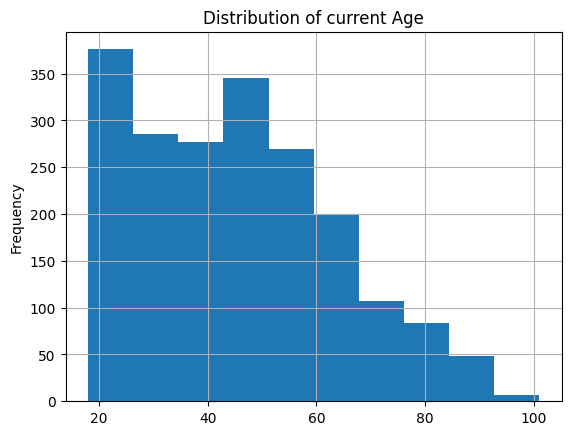

In [160]:
users_data['current_age'].plot(kind = 'hist', title = 'Distribution of current Age', grid = True)
#most lie between 20 - 60

In [161]:
users_data['gender'].value_counts(normalize=True)

gender
0    0.508
1    0.492
Name: proportion, dtype: float64

# Customer Segmentation

Customer Segmentation — grouping customers based on their spending behavior, risk, card usage, and demographic/financial profiles, using available data.

In [137]:
tnx_data = transactions_data.copy()

 # --- Feature 1: Basic Transaction Stats (Positive Only) ---

positives_txns = transactions_data[transactions_data['amount'] > 0]

tnx_stats =  positives_txns.groupby('client_id').agg(
    total_txns = ('id', 'count'),
    total_spent = ('amount', 'sum'),
    avg_txn_amount = ('amount', 'mean'),
    online_txn = ('use_chip', lambda x : (x == 'Online Transaction').sum()),
    swipe_txn = ('use_chip', lambda x : (x == 'Swipe Transaction').sum()),
    chip_txns = ('use_chip', lambda x : (x == 'Chip Transaction').sum())
).reset_index()



In [138]:
tnx_data['is_refund'] = tnx_data['amount'] < 0
refund_freq = tnx_data.groupby('client_id')['is_refund'].sum().reset_index().rename(columns={'is_refund': 'refund_count'})

In [139]:
error_cols = [
    'Technical Glitch', 'Bad Expiration', 'Bad Card Number', 
    'Insufficient Balance', 'Bad PIN', 'Bad CVV', 'Bad Zipcode'
]

# Create a new column `any_error` which is True if any error occurred
tnx_data['any_error'] = tnx_data[error_cols].sum(axis=1) > 0

# Calculate the error rate (mean of `any_error` for each user)
error_rates = tnx_data.groupby('client_id').agg(
    txn_error_rate=('any_error', 'mean')
).reset_index()

# Loop through error columns to calculate the specific error rates for each user
for col in error_cols:
    col_name = f"{col.lower().replace(' ', '_')}_rate"
    temp = tnx_data.groupby('client_id')[col].mean().reset_index().rename(columns={col: col_name})
    error_rates = error_rates.merge(temp, on='client_id', how='left')

In [140]:
customer_features = tnx_stats.merge(refund_freq, on='client_id', how='left')#.merge(error_rates, on='client_id', how='left')

In [141]:
customer_features.head()

,client_id,total_txns,total_spent,avg_txn_amount,online_txn,swipe_txn,chip_txns,refund_count
0,0,12160,703359.67,57.842078,932,5791,5437,623
1,1,9931,352054.37,35.450042,3947,5310,674,140
2,2,10104,331947.27,32.853055,675,6036,3393,506
3,3,5947,286810.46,48.227755,582,3973,1392,54
4,4,14386,663287.36,46.106448,430,8430,5526,652


In [169]:
users_data.rename(columns={'id': 'client_id'}, inplace=True)
full_customer_data = customer_features.merge(users_data, on='client_id', how='left')
full_customer_data.head()

,client_id,total_txns,total_spent,avg_txn_amount,online_txn,swipe_txn,chip_txns,refund_count,current_age,birth_year,gender,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards,debt_to_income_ratio,income_vs_area
0,0,12160,703359.67,57.842078,932,5791,5437,623,33,1986,1,43.59,-70.33,29237.0,59613.0,36199.0,763,4,0.607233,30376.0
1,1,9931,352054.37,35.450042,3947,5310,674,140,43,1976,0,30.44,-87.18,22247.0,45360.0,14587.0,704,3,0.321583,23113.0
2,2,10104,331947.27,32.853055,675,6036,3393,506,48,1971,1,40.84,-73.87,13461.0,27447.0,80850.0,673,5,2.945677,13986.0
3,3,5947,286810.46,48.227755,582,3973,1392,54,49,1970,1,33.89,-98.51,13705.0,27943.0,18693.0,681,4,0.668969,14238.0
4,4,14386,663287.36,46.106448,430,8430,5526,652,54,1965,0,47.61,-122.30,37485.0,76431.0,115362.0,716,5,1.509361,38946.0


In [170]:
full_customer_data.columns

Index(['client_id', 'total_txns', 'total_spent', 'avg_txn_amount',
       'online_txn', 'swipe_txn', 'chip_txns', 'refund_count', 'current_age',
       'birth_year', 'gender', 'latitude', 'longitude', 'per_capita_income',
       'yearly_income', 'total_debt', 'credit_score', 'num_credit_cards',
       'debt_to_income_ratio', 'income_vs_area'],
      dtype='object')

In [208]:
clustering_data = full_customer_data[['total_txns', 'total_spent', 'avg_txn_amount',
       'online_txn', 'swipe_txn', 'chip_txns', 'refund_count', 'current_age',
       'birth_year', 'gender', 'per_capita_income',
       'yearly_income', 'total_debt', 'credit_score', 'num_credit_cards',
       'debt_to_income_ratio', 'income_vs_area']]
clustering_data.head()

,total_txns,total_spent,avg_txn_amount,online_txn,swipe_txn,chip_txns,refund_count,current_age,birth_year,gender,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards,debt_to_income_ratio,income_vs_area
0,12160,703359.67,57.842078,932,5791,5437,623,33,1986,1,29237.0,59613.0,36199.0,763,4,0.607233,30376.0
1,9931,352054.37,35.450042,3947,5310,674,140,43,1976,0,22247.0,45360.0,14587.0,704,3,0.321583,23113.0
2,10104,331947.27,32.853055,675,6036,3393,506,48,1971,1,13461.0,27447.0,80850.0,673,5,2.945677,13986.0
3,5947,286810.46,48.227755,582,3973,1392,54,49,1970,1,13705.0,27943.0,18693.0,681,4,0.668969,14238.0
4,14386,663287.36,46.106448,430,8430,5526,652,54,1965,0,37485.0,76431.0,115362.0,716,5,1.509361,38946.0


In [209]:
clustering_data.isna().sum()

total_txns              0
total_spent             0
avg_txn_amount          0
online_txn              0
swipe_txn               0
chip_txns               0
refund_count            0
current_age             0
birth_year              0
gender                  0
per_capita_income       0
yearly_income           0
total_debt              0
credit_score            0
num_credit_cards        0
debt_to_income_ratio    0
income_vs_area          0
dtype: int64

In [210]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(clustering_data)

In [211]:
scaled_data.shape

(1219, 17)

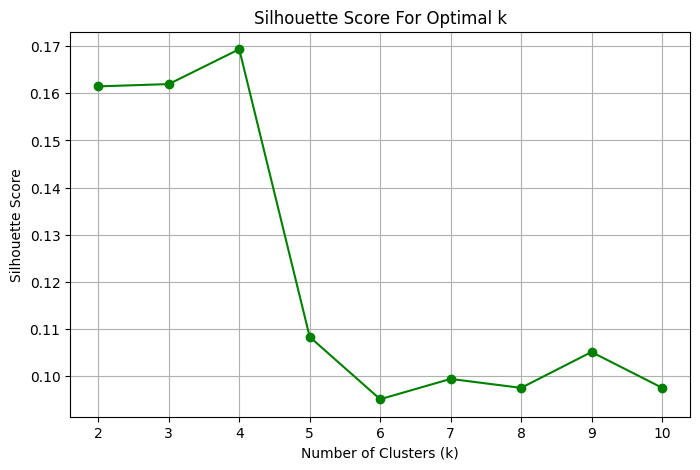

In [212]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, labels)
    silhouette_scores.append(score)

# Plot the silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, 'go-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score For Optimal k')
plt.grid(True)
plt.show()


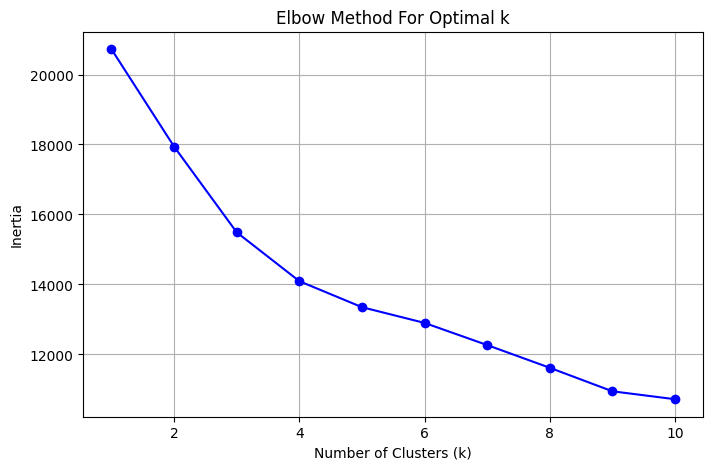

In [213]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

# Plot the elbow
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()

Deciding 4 as our number of clusters.

In [214]:
kmeans = KMeans(n_clusters=4, random_state=42)
cluster_labels = kmeans.fit_predict(scaled_data)

# Add the cluster labels to your merged data
clustering_data['cluster'] = cluster_labels

C:\Users\Vinay\AppData\Local\Temp\ipykernel_9520\11183071.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clustering_data['cluster'] = cluster_labels


In [222]:
cluster_centers_scaled = kmeans.cluster_centers_

# Convert the cluster centers back to the original scale (if you scaled the data)
cluster_centers_original = scaler.inverse_transform(cluster_centers_scaled)
cluster_centers_df = pd.DataFrame(cluster_centers_original, columns=clustering_data.columns[:-1])  # exclude 'cluster' column
cluster_centers_df

,total_txns,total_spent,avg_txn_amount,online_txn,swipe_txn,chip_txns,refund_count,current_age,birth_year,gender,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards,debt_to_income_ratio,income_vs_area
0,18903.681081,946462.761189,50.714049,3360.816216,9327.491892,6215.372973,1237.070270,51.313514,1967.848649,0.486486,24218.681081,47757.189189,61600.989189,713.562162,3.837838,1.339515,23538.508108
1,11309.736842,910736.205658,84.970512,1434.973684,5704.539474,4170.223684,630.394737,49.960526,1969.236842,0.500000,52188.526316,105774.355263,144781.236842,713.921053,3.644737,1.452486,53585.828947
2,8045.400915,390411.896235,50.267747,819.135671,4272.657012,2953.608232,377.667683,44.934451,1974.254573,0.513720,20638.958841,42016.475610,67047.861280,711.152439,3.228659,1.612435,21377.516768
3,9936.168874,460042.378278,47.533934,937.294702,5330.268212,3668.605960,417.178808,72.509934,1946.688742,0.437086,20508.754967,34973.642384,15096.099338,717.317881,4.665563,0.455320,14464.887417


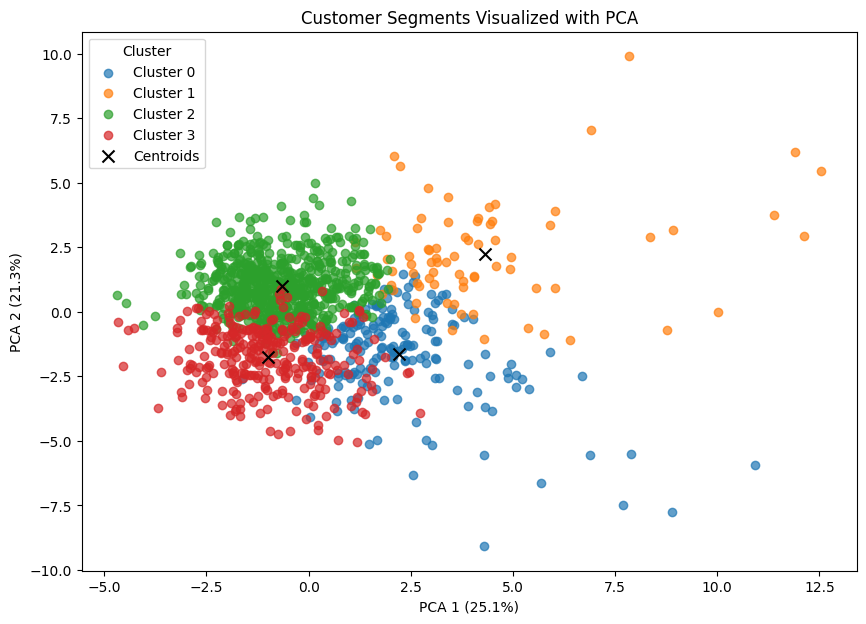

In [245]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(pca_components, columns=['PCA1', 'PCA2'])
pca_df['cluster'] = cluster_labels


plt.figure(figsize=(10, 7))

# Plot each cluster with label
for cluster in sorted(pca_df['cluster'].unique()):
    clustered_data = pca_df[pca_df['cluster'] == cluster]
    plt.scatter(clustered_data['PCA1'], clustered_data['PCA2'],
                label=f'Cluster {cluster}', alpha=0.7)

cluster_centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(cluster_centers_pca[:, 0], cluster_centers_pca[:, 1],
            c='black', marker='x', s=75, label='Centroids', alpha=1)



plt.title('Customer Segments Visualized with PCA')
explained_var = pca.explained_variance_ratio_
plt.xlabel(f'PCA 1 ({explained_var[0]*100:.1f}%)')
plt.ylabel(f'PCA 2 ({explained_var[1]*100:.1f}%)')
plt.legend(title='Cluster')

plt.show()